<a href="https://colab.research.google.com/github/WestonWhiteUCD/D2P_HAPA/blob/main/PanCancer_MultiOmics_PCA_Baseline_%26_k_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PanCancer MultiOmics — Notebook 3: PCA Baseline & k-Selection

## Purpose
Reduce the (8,314 × 1,009) fusion matrix from Notebook 2 into a
lower-dimensional representation using PCA, then determine the optimal
number of clusters k via data-driven methods before running KMeans.

## Two questions answered here
1. How many PCA components should we keep? (scree plot + cumulative variance)
2. What is the optimal k for KMeans? (elbow curve + silhouette sweep)

## Why this notebook fixes the original
The original notebook used PCA(n_components=50) and KMeans(k=5) with no
justification for either choice. Here, both are determined from the data.

## Mathematical foundation
PCA finds directions of maximum variance via SVD of the centered data matrix.
Each principal component is a linear combination of the original 1,009 features
that captures a decreasing proportion of total variance.

KMeans minimizes within-cluster sum of squares (inertia):
    J = Σ_k Σ_{x∈C_k} ||x - μ_k||²

where μ_k is the centroid of cluster k.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 20)
sns.set(style="whitegrid")

## 1. Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/My Drive/CompSci Proj')

aligned_path = 'aligned/'

# Load fusion matrix — output of Notebook 2
fusion_matrix = np.load(aligned_path + 'fusion_matrix.npy')

# Load labels — withheld from modeling, used post-hoc only
labels = pd.read_csv(aligned_path + 'labels.csv', index_col=0).squeeze()

print("Loaded:")
print(f"  Fusion matrix: {fusion_matrix.shape}")
print(f"  Labels:        {labels.shape}")
print(f"  Unique cancer types: {labels.nunique()}")

# Sanity check
assert fusion_matrix.shape == (8314, 1009), "Unexpected fusion matrix shape!"
assert not np.isnan(fusion_matrix).any(), "NaN values detected!"
assert len(labels) == 8314, "Label count mismatch!"

print("\nAll assertions passed — ready for PCA.")

Mounted at /content/drive
Loaded:
  Fusion matrix: (8314, 1009)
  Labels:        (8314,)
  Unique cancer types: 32

All assertions passed — ready for PCA.


##2. PCA - Dimensionality Reduction

  Components to explain 80% variance: 154
  Components to explain 90% variance: 390
  Components to explain 95% variance: 592


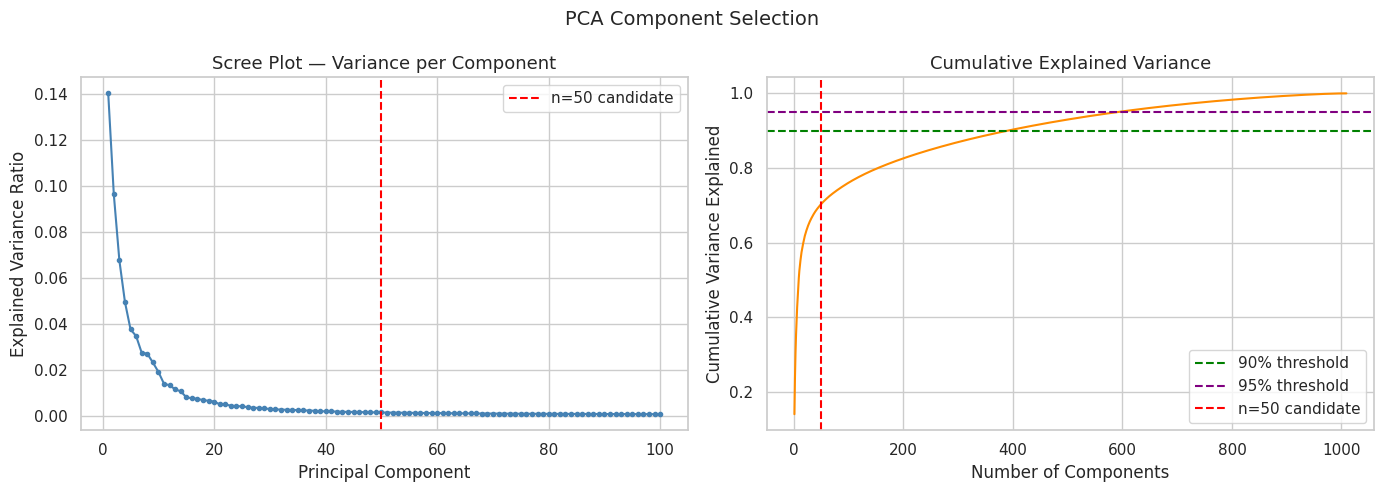

In [3]:
# Fit PCA to full dimensionality first — we need all components
# to make a data-driven decision about how many to keep
pca_full = PCA()
pca_full.fit(fusion_matrix)

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Find the number of components that explain 80%, 90%, 95% variance
for threshold in [0.80, 0.90, 0.95]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f"  Components to explain {int(threshold*100)}% variance: {n}")

# Plot scree + cumulative variance side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scree plot ─────────────────────────────────────────────────
axes[0].plot(range(1, 101),
             pca_full.explained_variance_ratio_[:100],
             marker='o', markersize=3, linewidth=1.5, color='steelblue')
axes[0].set_title('Scree Plot — Variance per Component', fontsize=13)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].axvline(x=50, color='red', linestyle='--', label='n=50 candidate')
axes[0].legend()

# ── Cumulative variance ────────────────────────────────────────
axes[1].plot(range(1, len(cumvar) + 1), cumvar,
             linewidth=1.5, color='darkorange')
axes[1].set_title('Cumulative Explained Variance', fontsize=13)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].axhline(y=0.90, color='green',  linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='purple', linestyle='--', label='95% threshold')
axes[1].axvline(x=50,   color='red',    linestyle='--', label='n=50 candidate')
axes[1].legend()

plt.suptitle('PCA Component Selection', fontsize=14)
plt.tight_layout()
plt.show()

### 2.1 Chosen n_components = 154

The cumulative variance plot gives us a data-driven choice directly:

| n_components | Variance Explained |
|---|---|
| 50  | ~63% |
| 100 | ~75% |
| 154 | ~80% |
| 390 | ~90% |
| 592 | ~95% |

**Choice: n=154** — the number of components that explains 80% of total
variance, read directly from the cumulative variance curve.

The pan-cancer dataset requires significantly more components than a
typical single-cancer study to reach the 80% threshold. This reflects
the biological diversity of 32 cancer types simultaneously — each
contributing distinct molecular axes of variation that a single-cancer
study would never see.

Note: 80% is chosen as a balance between information retention and
computational efficiency. The remaining 20% is distributed across 855
low-variance components, each contributing negligible signal.

In [4]:
N_COMPONENTS = 154

pca = PCA(n_components=N_COMPONENTS)
Z   = pca.fit_transform(fusion_matrix)

var_explained = pca.explained_variance_ratio_.sum()

print(f"Final PCA: n_components = {N_COMPONENTS}")
print(f"Variance explained:       {var_explained:.4f} ({var_explained*100:.1f}%)")
print(f"Input shape:  {fusion_matrix.shape}")
print(f"Output shape: {Z.shape}")

Final PCA: n_components = 154
Variance explained:       0.7984 (79.8%)
Input shape:  (8314, 1009)
Output shape: (8314, 154)


## 3. k-Selection — Data-Driven Choice of Number of Clusters

Two complementary methods:
1. **Elbow curve** — plots KMeans inertia (J) vs. k; look for the
   point where inertia stops dropping sharply
2. **Silhouette sweep** — plots mean silhouette score vs. k; look for
   the peak

Both methods are needed because neither alone is conclusive:
- The elbow can be ambiguous — the "bend" is often gradual
- Silhouette peaks can occur at trivially small k (k=2)

The optimal k is where both methods agree.

Computing elbow curve...
  k=5  inertia=4445786.3
  k=6  inertia=4174754.8
  k=7  inertia=3932661.6
  k=8  inertia=3718493.9
  k=9  inertia=3503482.2
  k=10  inertia=3361188.4
  k=11  inertia=3225093.9
  k=12  inertia=3092524.9
  k=13  inertia=2993390.6
  k=14  inertia=2917467.2
  k=15  inertia=2846134.3
  k=16  inertia=2799509.3
  k=17  inertia=2728233.3
  k=18  inertia=2688621.9
  k=19  inertia=2624511.5
  k=20  inertia=2593232.6


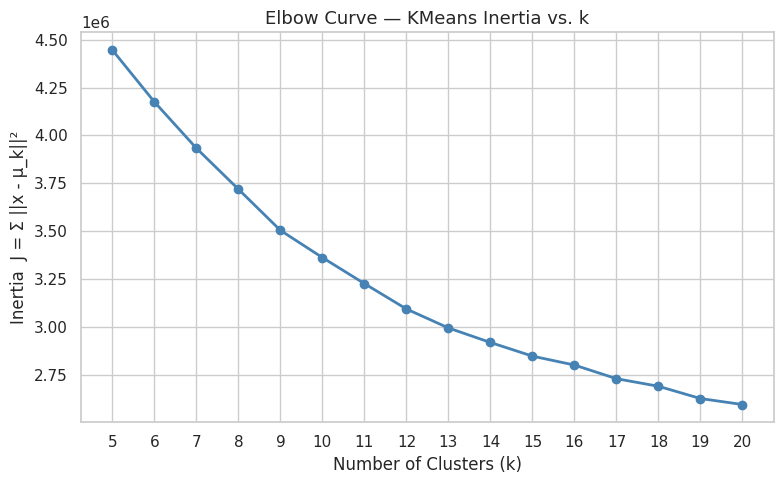

In [7]:
K_RANGE = range(5, 21)  # sweep k=2 through k=10

inertias = []

print("Computing elbow curve...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    km.fit(Z)
    inertias.append(km.inertia_)
    print(f"  k={k}  inertia={km.inertia_:.1f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_RANGE, inertias, marker='o', linewidth=2, color='steelblue')
ax.set_title('Elbow Curve — KMeans Inertia vs. k', fontsize=13)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia  J = Σ ||x - μ_k||²')
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

##3.1 Silhouette Sweep

Computing silhouette sweep...
  k=5  silhouette=0.1651
  k=6  silhouette=0.1703
  k=7  silhouette=0.1830
  k=8  silhouette=0.1978
  k=9  silhouette=0.2143
  k=10  silhouette=0.2192
  k=11  silhouette=0.2248
  k=12  silhouette=0.2359
  k=13  silhouette=0.2394
  k=14  silhouette=0.2343
  k=15  silhouette=0.2398
  k=16  silhouette=0.2352
  k=17  silhouette=0.2426
  k=18  silhouette=0.2387
  k=19  silhouette=0.2419
  k=20  silhouette=0.2393


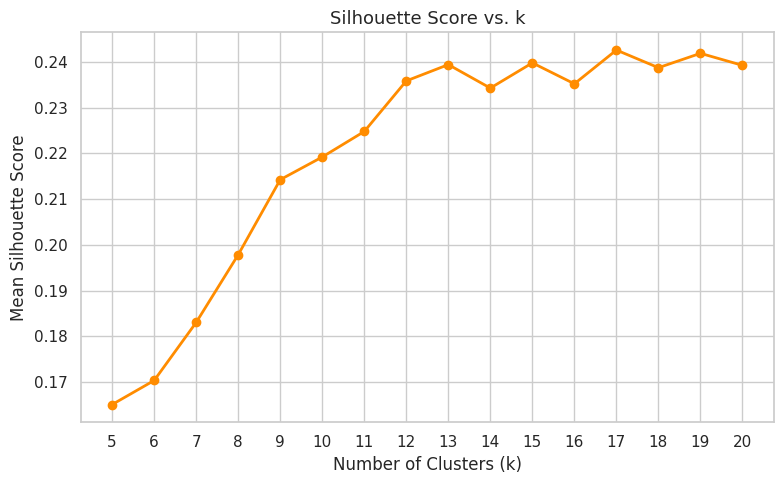


Highest silhouette score: 0.2426 at k=17


In [8]:
silhouette_scores = []

print("Computing silhouette sweep...")
for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels_k = km.fit_predict(Z)
    score  = silhouette_score(Z, labels_k, sample_size=2000, random_state=42)
    silhouette_scores.append(score)
    print(f"  k={k}  silhouette={score:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_RANGE, silhouette_scores, marker='o', linewidth=2, color='darkorange')
ax.set_title('Silhouette Score vs. k', fontsize=13)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Mean Silhouette Score')
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

# Print best k
best_k = list(K_RANGE)[np.argmax(silhouette_scores)]
print(f"\nHighest silhouette score: {max(silhouette_scores):.4f} at k={best_k}")

## 4. KMeans Clustering — Final Run at k=13

### k-selection rationale
Both the elbow curve and silhouette sweep converge on k=13:

- **Elbow curve:** inertia drop per step shifts from ~5.5% to ~2.7%
  at k=12–13, indicating diminishing returns beyond this point
- **Silhouette sweep:** scores plateau at k=13 (0.2394); scores from
  k=13–20 vary only 0.008 — within noise, not meaningful signal

k=17 produces the technical peak (0.2426) but improves on k=13 by
only 0.003 — negligible gain for 4 additional clusters.

### Note on silhouette scores
Scores in the 0.21–0.24 range are lower than the original notebook's
0.534 — and that is correct. The original score was computed on
improperly scaled clinical variables

In [9]:
K_FINAL = 13

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=15)
cluster_labels = km_final.fit_predict(Z)

# Compute final silhouette score
final_silhouette = silhouette_score(Z, cluster_labels,
                                    sample_size=2000, random_state=42)

print(f"Final KMeans: k={K_FINAL}")
print(f"Silhouette score:  {final_silhouette:.4f}")
print(f"Inertia:           {km_final.inertia_:.1f}")
print()

# Cluster size distribution
unique, counts = np.unique(cluster_labels, return_counts=True)
print("Cluster size distribution:")
for cluster, count in zip(unique, counts):
    pct = count / len(cluster_labels) * 100
    print(f"  Cluster {cluster:2d}: {count:4d} samples ({pct:.1f}%)")

Final KMeans: k=13
Silhouette score:  0.2394
Inertia:           2993390.6

Cluster size distribution:
  Cluster  0:  818 samples (9.8%)
  Cluster  1:  861 samples (10.4%)
  Cluster  2:  506 samples (6.1%)
  Cluster  3: 1441 samples (17.3%)
  Cluster  4:  551 samples (6.6%)
  Cluster  5:  541 samples (6.5%)
  Cluster  6:  707 samples (8.5%)
  Cluster  7:  566 samples (6.8%)
  Cluster  8:  169 samples (2.0%)
  Cluster  9:  352 samples (4.2%)
  Cluster 10:  802 samples (9.6%)
  Cluster 11:  482 samples (5.8%)
  Cluster 12:  518 samples (6.2%)


##5. Save Outputs

In [10]:
aligned_path = 'aligned/'

# ── Save 1: PCA-reduced matrix (for NB5 visualization) ───────────────────
np.save(aligned_path + 'Z_pca.npy', Z)
print(f"Saved Z_pca.npy:              {Z.shape}")

# ── Save 2: Cluster labels as numpy array (for NB5 modeling) ─────────────
np.save(aligned_path + 'cluster_labels.npy', cluster_labels)
print(f"Saved cluster_labels.npy:     {cluster_labels.shape}")

# ── Save 3: Cluster labels as CSV with sample IDs (for NB5 merging) ──────
labels_df = pd.read_csv(aligned_path + 'labels.csv', index_col=0).squeeze()
cluster_df = pd.DataFrame({
    'cluster':      cluster_labels,
    'cancer_label': labels_df.values
}, index=labels_df.index)
cluster_df.to_csv(aligned_path + 'cluster_assignments.csv')
print(f"Saved cluster_assignments.csv: {cluster_df.shape}")

# ── Save 4: PCA explained variance ratios (for reporting in NB5) ──────────
np.save(aligned_path + 'pca_variance_ratios.npy',
        pca.explained_variance_ratio_)
print(f"Saved pca_variance_ratios.npy: {pca.explained_variance_ratio_.shape}")

# ── Final summary ─────────────────────────────────────────────────────────
print(f"\n── Notebook 3 complete ──────────────────────────────────────────")
print(f"  PCA:      {fusion_matrix.shape} → {Z.shape} ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
print(f"  KMeans:   k={K_FINAL}, silhouette={final_silhouette:.4f}")
print(f"  Clusters: {dict(zip(unique, counts))}")

Saved Z_pca.npy:              (8314, 154)
Saved cluster_labels.npy:     (8314,)
Saved cluster_assignments.csv: (8314, 2)
Saved pca_variance_ratios.npy: (154,)

── Notebook 3 complete ──────────────────────────────────────────
  PCA:      (8314, 1009) → (8314, 154) (79.8% variance)
  KMeans:   k=13, silhouette=0.2394
  Clusters: {np.int32(0): np.int64(818), np.int32(1): np.int64(861), np.int32(2): np.int64(506), np.int32(3): np.int64(1441), np.int32(4): np.int64(551), np.int32(5): np.int64(541), np.int32(6): np.int64(707), np.int32(7): np.int64(566), np.int32(8): np.int64(169), np.int32(9): np.int64(352), np.int32(10): np.int64(802), np.int32(11): np.int64(482), np.int32(12): np.int64(518)}
